In [1]:
import pandas as pd
import pyarrow.parquet as pq
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [11]:
def plot_bar_chart(df, x, hue, title, stat= 'Percent', facet=None, stacked_by=None):
    df = df[df['statistics'] == stat]
    plt.figure(figsize=(10,6))    
    
    if stacked_by:
        # Group and pivot for stacked bar chart (use mean for percentages)
        if facet:
            pivot_df = df.groupby([x, hue, facet])['value'].mean().reset_index()
            for fac in df[facet].unique():
                sub = pivot_df[pivot_df[facet] == fac]
                pivot = sub.pivot(index=x, columns=hue, values='value').fillna(0)
                ax = pivot.plot(kind='bar', stacked=True, ax=plt.gca())
                plt.legend(title=stacked_by)
                plt.xticks(rotation=90)
                # Add labels to each bar segment
                for cidx, col in enumerate(pivot_df.columns):
                    for ridx, val in enumerate(pivot_df[col]):
                        if val > 0:
                            bottom = pivot_df.iloc[ridx, :cidx].sum()
                            ax.text(ridx, bottom + val/2, f"{val:.1f}", ha='center', va='center', fontsize=9, color="white" if val > 5 else "black")
        else: 
            pivot_df = df.groupby([x, hue])['value'].mean().unstack(fill_value=0)
            ax = pivot_df.plot(kind='bar', stacked=True, ax=plt.gca())
            plt.legend(title=stacked_by)
            plt.xticks(rotation=90)
            # Add labels to each bar segment
            for cidx, col in enumerate(pivot_df.columns):
                for ridx, val in enumerate(pivot_df[col]):
                    if val > 0:
                        bottom = pivot_df.iloc[ridx, :cidx].sum()
                        ax.text(ridx, bottom + val/2, f"{val:.1f}", ha='center', va='center', fontsize=9, color="white" if val > 5 else "black")
    else:
        # Regular bar chart
        if facet:
            agg_df = df.groupby([x, hue, facet])['value'].mean().reset_index()
            ax = sns.catplot(data=agg_df, x=x, y='value', hue=hue, col=facet, kind='bar', height=5, aspect=1.2)
            ax.set_titles(col_template="{col_name}")

            # add labels on bars
            for ax_i in ax.axes.flatten():
                ax_i.set_ylabel('Average Percentage')
                ax_i.set_xticklabels(ax_i.get_xticklabels(), rotation=90)
                for container in ax_i.containers:
                    ax_i.bar_label(container, fmt='%.1f', padding=2)
                    
            plt.subplots_adjust(top=0.85)
            plt.suptitle(title)

        else:
            agg_df = df.groupby([x, hue])['value'].mean().reset_index()
            ax = sns.barplot(data=agg_df, x=x, y='value', hue=hue)
            plt.xticks(rotation=90)

            # Add labels on bars
            for container in ax.containers:
                ax.bar_label(container, fmt='%.1f', padding=2)
    
            plt.title(title)
            plt.xlabel(x)
            plt.ylabel('Average Percentage')
            plt.tight_layout()
            plt.show()

In [3]:
# Load the Parquet file
df = pq.read_table('data/healthcare-access/healthcare_access_2017.parquet').to_pandas()

In [31]:
# display df
df.head()

,geo,aboriginal_identity,age_group,gender,statistics,value,regular_medical_doctor_status,contact_with_health_professional_12mo,received_dental_care_3yr,healthcare_required_not_received_12mo
1096,Canada,First Nations (North American Indian),15 to 24 years,Both sexes,Number of persons,85730.0,Has a regular medical doctor,None,None,None
1097,Canada,First Nations (North American Indian),15 to 24 years,Both sexes,Percent,73.5,Has a regular medical doctor,None,None,None
1098,Canada,First Nations (North American Indian),15 to 24 years,Both sexes,Number of persons,29410.0,Does not have a regular medical doctor,None,None,None
1099,Canada,First Nations (North American Indian),15 to 24 years,Both sexes,Percent,25.2,Does not have a regular medical doctor,None,None,None
1100,Canada,First Nations (North American Indian),15 to 24 years,Both sexes,Number of persons,2950.0,Does not have a regular medical doctor: no med...,None,None,None


# Remove Total Values

In [13]:
# remove values starting with 'Total,' across all columns
for col in df.columns:
    df = df[~df[col].astype(str).str.startswith('Total,')]

# Rename sex with gender

In [15]:
# rename sex column with gender for consistency
df = df.rename(columns={'sex':'gender'})

# Shorten Values

In [55]:
def shorten_response(col, val):
    """
    Shortens survey responses for a given column and value.
    """
    if str(val).startswith('Not specified'):
            return 'Not specified'
    if col == 'received_dental_care_3yr':
        if str(val).startswith('Has not received'):
            return 'Has not received'
        elif str(val).startswith('Received'):
            return 'Received'
        else:
            return val
    # Add more cases for other columns if needed
    else:
        return val

In [56]:
df.columns

Index(['geo', 'aboriginal_identity', 'age_group', 'gender', 'statistics',
       'value', 'regular_medical_doctor_status',
       'contact_with_health_professional_12mo', 'received_dental_care_3yr',
       'healthcare_required_not_received_12mo',
       'received_dental_care_3yr_short'],
      dtype='object')

In [57]:
shorted_cols = ['regular_medical_doctor_status',
       'contact_with_health_professional_12mo', 
       'received_dental_care_3yr',
       'healthcare_required_not_received_12mo',
       'received_dental_care_3yr_short'
]

for col in shorted_cols:
    df[col] = df[col].apply(lambda v: shorten_response(col, v))

# Regular Medical Doctor Status

/var/folders/8n/4krln465113bpt4x1bnwnwr80000gn/T/ipykernel_32738/884905360.py:61: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all axes decorations.
  plt.tight_layout()


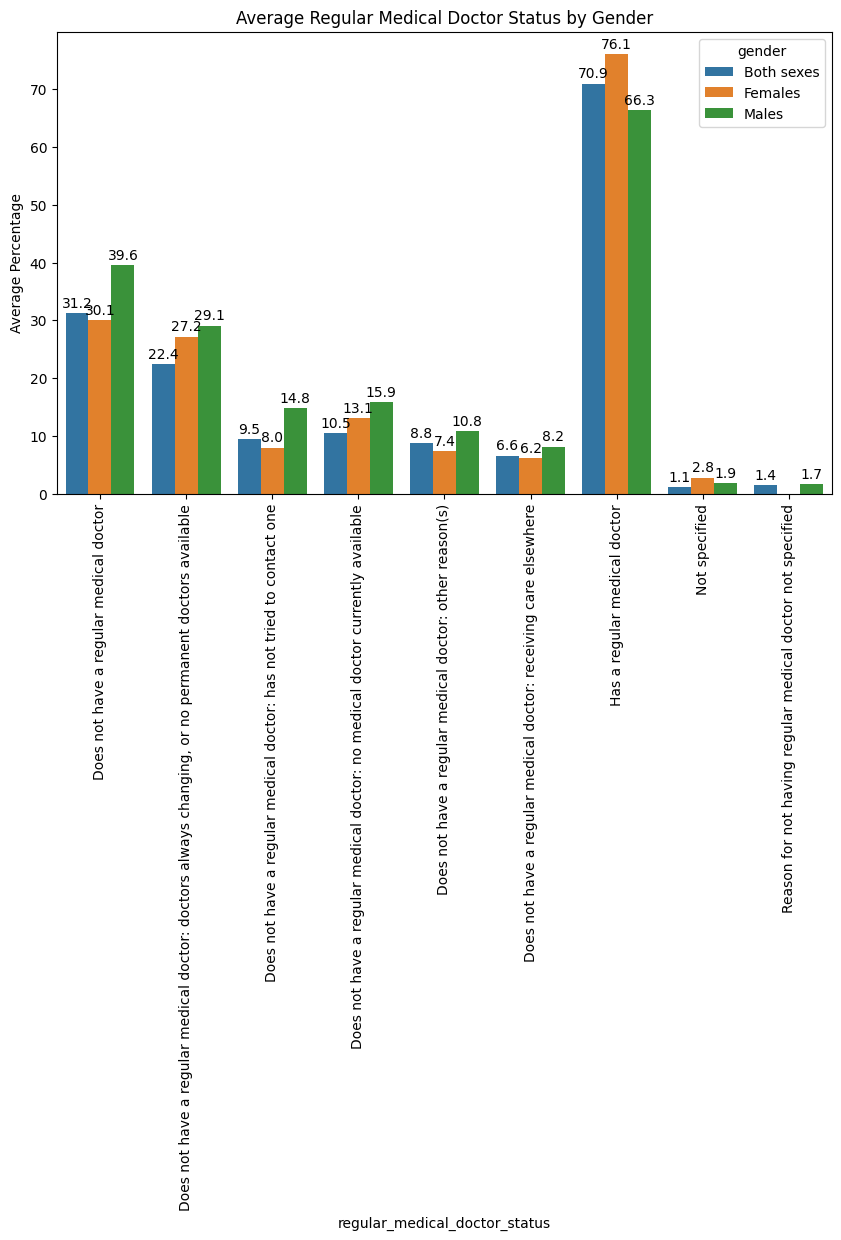

In [58]:
# plot regular_medical_doctor_status
plot_bar_chart(df,
    x='regular_medical_doctor_status',
    hue='gender',
    title='Average Regular Medical Doctor Status by Gender',
    stat='Percent',
    stacked_by=None
)

/var/folders/8n/4krln465113bpt4x1bnwnwr80000gn/T/ipykernel_32738/884905360.py:61: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all axes decorations.
  plt.tight_layout()


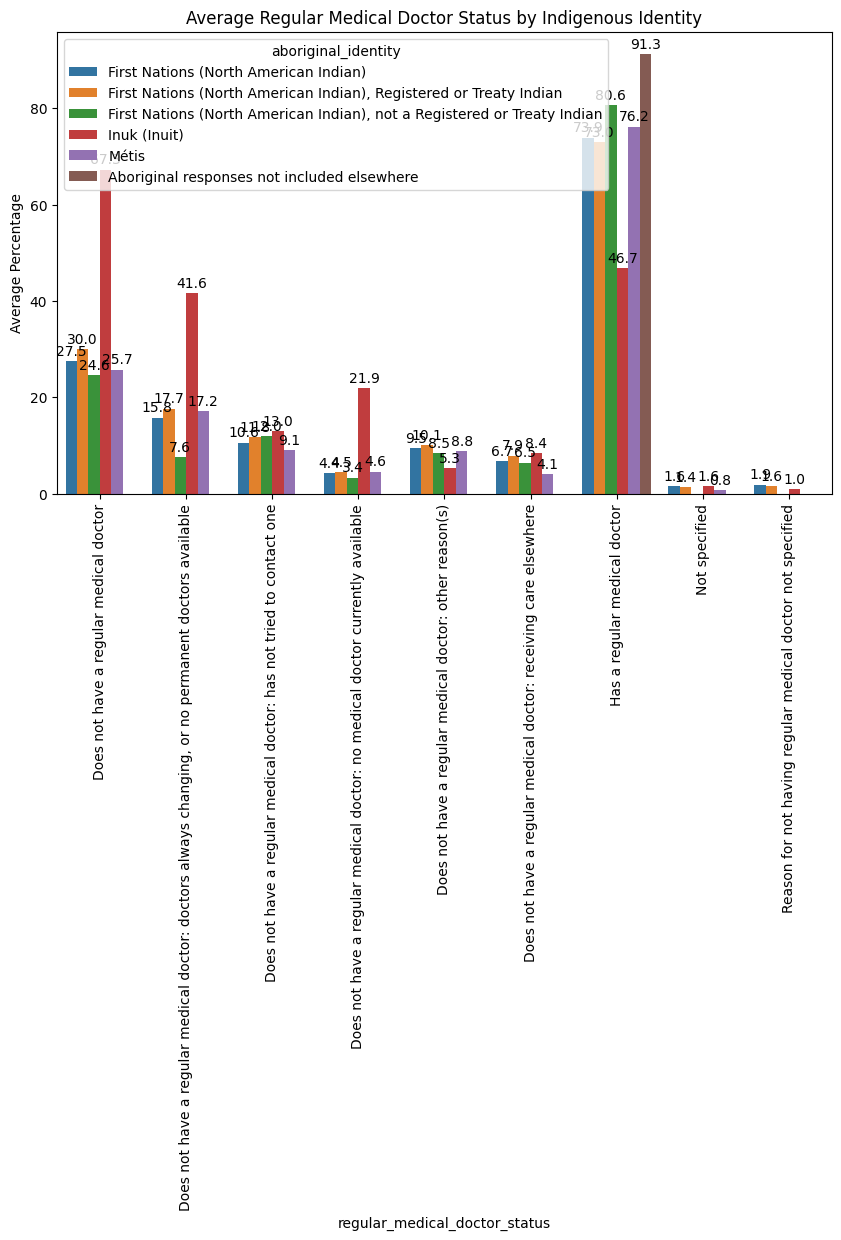

In [59]:
# plot regular_medical_doctor_status
plot_bar_chart(df,
    x='regular_medical_doctor_status',
    hue='aboriginal_identity',
    title='Average Regular Medical Doctor Status by Indigenous Identity',
    stat='Percent',
    stacked_by=None
)

# Contact with health professional past 12 months

In [60]:
df.columns

Index(['geo', 'aboriginal_identity', 'age_group', 'gender', 'statistics',
       'value', 'regular_medical_doctor_status',
       'contact_with_health_professional_12mo', 'received_dental_care_3yr',
       'healthcare_required_not_received_12mo',
       'received_dental_care_3yr_short'],
      dtype='object')

/var/folders/8n/4krln465113bpt4x1bnwnwr80000gn/T/ipykernel_32738/884905360.py:61: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all axes decorations.
  plt.tight_layout()


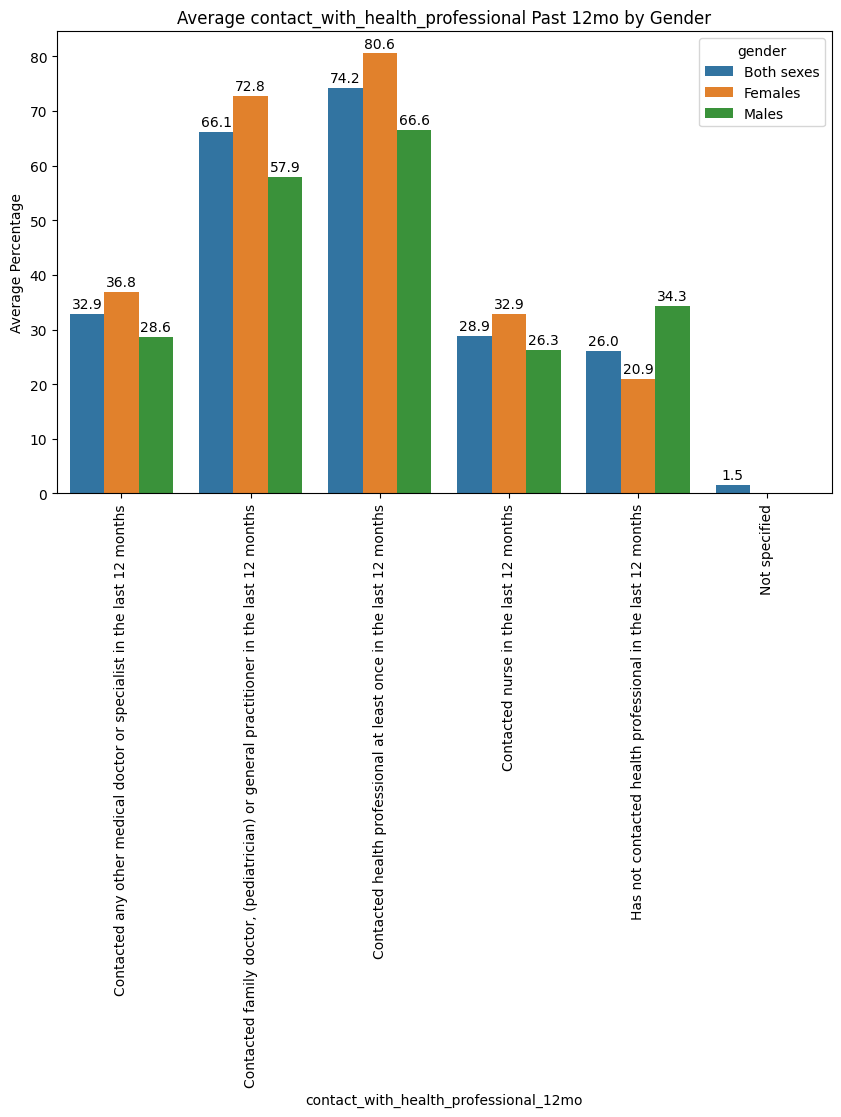

In [61]:
plot_bar_chart(df,
    x='contact_with_health_professional_12mo',
    hue='gender',
    title='Average contact_with_health_professional Past 12mo by Gender',
    stat='Percent',
    stacked_by=None
)

# Dental Care Past 3 years

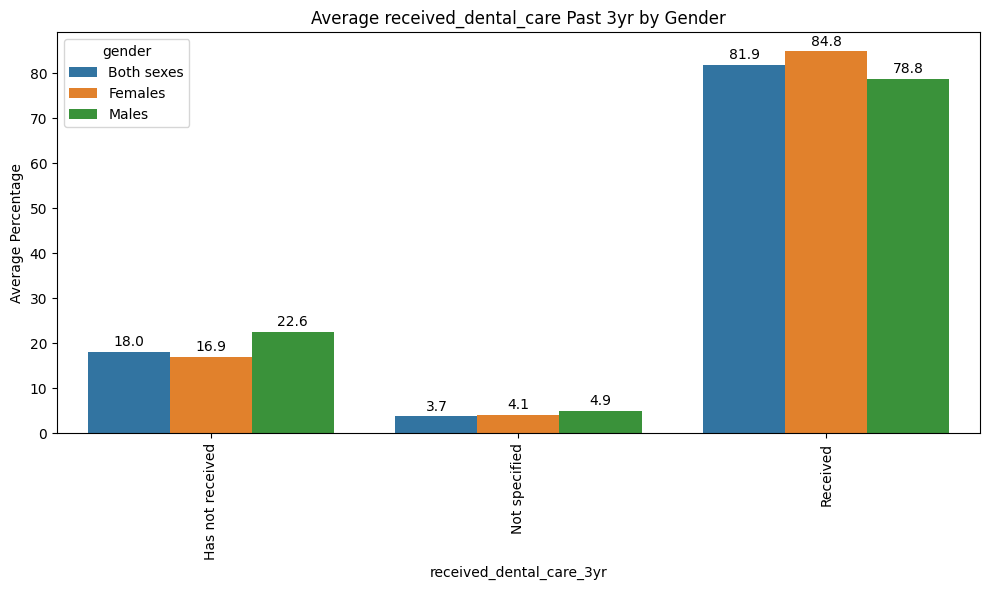

In [62]:
plot_bar_chart(df,
    x='received_dental_care_3yr',
    hue='gender',
    title='Average received_dental_care Past 3yr by Gender',
    stat='Percent',
    stacked_by=None
)

# Healthcare_required_not_received Past 12 months

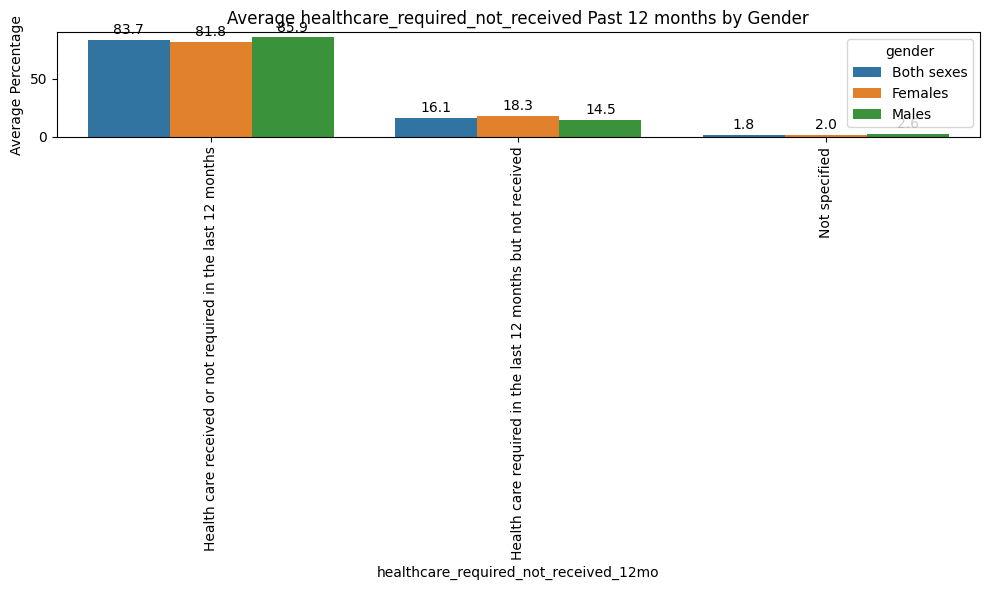

In [63]:
plot_bar_chart(df,
    x='healthcare_required_not_received_12mo',
    hue='gender',
    title='Average healthcare_required_not_received Past 12 months by Gender',
    stat='Percent',
    stacked_by=None
)

Next Steps:
* Compare to 2024 data
* Compare with genderal population (non-indigenous)